# RQ3: External Validation — School Specialty LLC (SSL)

**Purpose**: Validate TheLook predictive model against an independent dataset from a different domain (educational supplies vs. general e-commerce).

**Validation Levels**:
- **Level 1 (Pattern)**: Do the same features matter in both datasets?
- **Level 2 (Directional)**: Does the TheLook-trained model generalize to SSL accounts?

**SSL Data**: ~134K return-related order lines (~38K actual returns + ~96K no-charge replacements), ~13.6K accounts, 2024–2025

---

## 1. Setup & Imports

In [1]:
# Standard library imports
import sys
from pathlib import Path

# Add project root to path for src imports
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Module reloading for development
import importlib
modules_to_reload = [
    "src.config",
    "src.rq3_modeling",
    "src.rq3_validation",
    "src.rq3_visuals",
]
for module_name in modules_to_reload:
    if module_name in sys.modules:
        importlib.reload(sys.modules[module_name])

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Project imports
from src.config import (
    CUSTOMER_TARGETS_CSV,
    SSL_RETURNS_CSV,
    RQ3_CANDIDATE_FEATURES,
    RQ3_TARGET,
    AUC_THRESHOLD,
    REPORTS_DIR,
)
from src.rq3_modeling import (
    prepare_modeling_data,
    screen_features,
    train_and_evaluate,
    get_feature_importance,
    build_comparison_table,
    test_hypothesis,
)
from src.rq3_validation import (
    load_ssl_data,
    engineer_ssl_account_features,
    create_ssl_targets,
    validate_feature_patterns,
    validate_directional_predictions,
    build_validation_summary,
)

%matplotlib inline
sns.set_style("whitegrid")

print("Setup complete.")

Setup complete.


## 2. Train TheLook Model (Baseline)

Reproduce the TheLook pipeline to obtain the trained model, surviving features, and screening report for validation.

In [2]:
print("=" * 60)
print("THELOOK BASELINE: LOAD, PREP, SCREEN, TRAIN")
print("=" * 60)

# Load TheLook data
thelook_df = pd.read_csv(CUSTOMER_TARGETS_CSV)
print(f"TheLook data: {len(thelook_df):,} customers")

# Prepare (drop leakage, impute, split)
X_train, X_test, y_train, y_test = prepare_modeling_data(thelook_df)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

# Feature screening on training set
surviving_features, thelook_screening = screen_features(X_train, y_train)
print(f"Surviving features: {len(surviving_features)} / {len(RQ3_CANDIDATE_FEATURES)}")
for feat in surviving_features:
    print(f"  - {feat}")

# Apply surviving features
X_train_s = X_train[surviving_features]
X_test_s = X_test[surviving_features]

# Train models
results = train_and_evaluate(X_train_s, X_test_s, y_train, y_test)

# Display results
comparison = build_comparison_table(results)
print(f"\nTheLook Model Performance:")
for _, row in comparison.iterrows():
    print(f"  {row['model']:25s} AUC={row['test_auc']:.4f}  F1={row['f1']:.4f}")

THELOOK BASELINE: LOAD, PREP, SCREEN, TRAIN
TheLook data: 11,988 customers
Train: 9,590 | Test: 2,398
Surviving features: 7 / 12
  - return_frequency
  - customer_return_rate
  - avg_basket_size
  - avg_order_value
  - total_items
  - total_margin
  - avg_item_margin

TheLook Model Performance:
  Random Forest             AUC=0.9798  F1=0.8419
  Gradient Boosting         AUC=0.9795  F1=0.8484
  Logistic Regression       AUC=0.9687  F1=0.8256


In [3]:
# Select best model for directional validation
hypothesis = test_hypothesis(results)
best_model_name = hypothesis["best_model"]
best_model = results[best_model_name]["best_estimator"]

print(f"Best model: {best_model_name} (AUC={hypothesis['best_auc']:.4f})")
print(f"Using this model for directional validation against SSL data.")

# Prepare scaler for Logistic Regression (if that's the best model)
scaler = None
if best_model_name == "Logistic Regression":
    scaler = StandardScaler()
    scaler.fit(X_train_s)
    print("StandardScaler fitted for Logistic Regression.")

Best model: Random Forest (AUC=0.9798)
Using this model for directional validation against SSL data.


## 3. Load & Explore SSL Data

SSL data contains return-related order lines with two `Sales_Type` values:
- **RETURN** (28.4%): Actual return of goods — credit/refund issued, negative qty
- **ORDER** (71.6%): No-charge replacement shipments — CreditReturn Sales ≈ 0, positive qty

Feature engineering distinguishes these to produce accurate mappings.

In [4]:
print("=" * 60)
print("LOAD SSL DATA")
print("=" * 60)

ssl_raw = load_ssl_data()

print(f"\nSource: {SSL_RETURNS_CSV}")
print(f"Rows: {len(ssl_raw):,}")
print(f"Columns: {len(ssl_raw.columns)}")
print(f"Unique accounts: {ssl_raw['Bill To Act #'].nunique():,}")
print(f"Date range: {ssl_raw['Booked Date'].min()} to {ssl_raw['Booked Date'].max()}")

LOAD SSL DATA

Source: c:\Users\folij077\OneDrive - GUSCanada\SCHOOL\Winter 2026\Capstone\bQuery_theLook\unfc-capstone-project\data\raw\SSL_Returns_df_yoy.csv
Rows: 133,800
Columns: 82
Unique accounts: 13,616
Date range: 2024-01-02 00:00:00 to 2025-11-26 00:00:00


In [5]:
# Return type distribution
print("Return Type Distribution:")
print(ssl_raw["Return_Type"].value_counts())

Return Type Distribution:
Return_Type
No-Charge Replacement    82261
FC Return                27819
Vendor Return            13044
Unauthorized Return      10676
Name: count, dtype: int64


## 4. Engineer SSL Account Features

Aggregate SSL order lines to account level, producing features analogous to TheLook's 12 candidates. The `Sales_Type` column distinguishes actual returns from no-charge replacements.

| TheLook Feature | SSL Mapping | Sales_Type Scope |
|-----------------|-------------|------------------|
| `order_frequency` | Unique Order Number count per account | All lines |
| `return_frequency` | Count of RETURN lines only | RETURN only |
| `customer_return_rate` | RETURN lines / total lines | Both (ratio) |
| `avg_basket_size` | Mean Lines Per Order | All lines |
| `avg_order_value` | Mean Reference Sale Amount per order | All lines |
| `total_items` | Total lines per account | All lines |
| `total_sales` | Sum of Reference Sale Amount | All lines |
| `total_margin` | Sum of gross_financial_loss | All lines |
| `avg_item_price` | Mean Reference Sale Amount / \|Ordered Qty\| (CreditReturn Sales fallback on RETURN lines) | All lines |
| `avg_item_margin` | Mean gross_financial_loss per line | All lines |
| `customer_tenure_days` | Date range of Booked Date | All lines |
| `purchase_recency_days` | Days since last Booked Date | All lines |

**`avg_item_price` computation (updated):** Uses `Reference Sale Amount / |Ordered Qty|` from ALL line types as the primary source — semantically closest to TheLook's `avg_item_price` (original sale price per unit). ORDER lines carry `Reference Sale Amount` (the price of the item being replaced) but have `CreditReturn Sales ≈ $0`. Falls back to `|CreditReturn Sales / Ordered Qty|` on RETURN lines where `Reference Sale Amount` is unavailable. This increases account-level coverage from 37.7% (RETURN-only) to ~90%.

In [6]:
print("=" * 60)
print("ENGINEER SSL ACCOUNT FEATURES")
print("=" * 60)

ssl_accounts = engineer_ssl_account_features(ssl_raw)

print(f"\nAccounts: {len(ssl_accounts):,}")
print(f"Columns: {list(ssl_accounts.columns)}")
print(f"\nFeature summary:")
feature_cols = [
    f for f in RQ3_CANDIDATE_FEATURES if f in ssl_accounts.columns
]
ssl_accounts[feature_cols].describe().round(2)

ENGINEER SSL ACCOUNT FEATURES

Accounts: 13,616
Columns: ['account_id', 'order_frequency', 'return_frequency', 'avg_basket_size', 'total_items', 'total_sales', 'total_margin', 'avg_item_price', 'avg_item_margin', 'total_loss', 'customer_return_rate', 'customer_tenure_days', 'purchase_recency_days', 'avg_order_value']

Feature summary:


,order_frequency,return_frequency,customer_return_rate,avg_basket_size,avg_order_value,customer_tenure_days,purchase_recency_days,total_items,total_sales,total_margin,avg_item_price,avg_item_margin
count,13616.00,13616.00,13616.00,13616.00,13616.00,13616.00,13616.00,13616.00,13616.00,13616.00,12254.00,13616.00
mean,5.46,2.79,0.22,2.21,356.59,154.49,272.69,9.83,1752.06,601.64,188.19,91.46
std,40.39,27.61,0.35,3.71,1227.17,219.19,204.40,85.80,15273.96,4796.85,712.50,281.40
min,1.00,0.00,0.00,1.00,-455.08,0.00,0.00,1.00,-455.08,-8030.88,0.00,-2676.96
25%,1.00,0.00,0.00,1.00,25.52,0.00,84.00,1.00,38.50,22.48,16.24,10.98
50%,1.00,0.00,0.00,1.00,81.45,0.00,225.00,2.00,162.19,77.53,40.85,26.00
75%,3.00,1.00,0.33,2.00,245.96,351.00,455.00,6.00,751.88,311.90,117.96,70.82
max,4135.00,2743.00,1.00,112.19,36325.09,694.00,694.00,9091.00,1467949.65,472534.19,31803.84,7900.00


## 5. Create SSL Target Variable

Create `is_high_loss_account` using the 75th percentile of `total_loss`, mirroring TheLook methodology.

In [7]:
print("=" * 60)
print("CREATE SSL TARGET VARIABLE")
print("=" * 60)

ssl_accounts = create_ssl_targets(ssl_accounts)

print(f"\nTarget distribution (is_high_loss_account):")
print(ssl_accounts["is_high_loss_account"].value_counts())
print(f"\nHigh-loss rate: {ssl_accounts['is_high_loss_account'].mean():.2%}")
print(f"Total loss 75th percentile: ${np.percentile(ssl_accounts['total_loss'].dropna(), 75):,.2f}")

CREATE SSL TARGET VARIABLE

Target distribution (is_high_loss_account):
is_high_loss_account
0    10212
1     3404
Name: count, dtype: int64

High-loss rate: 25.00%
Total loss 75th percentile: $570.50


## 6. Level 1: Pattern Validation

Run the same 3-gate feature screening on SSL data independently and compare which features survive in both datasets.

In [8]:
print("=" * 60)
print("LEVEL 1: PATTERN VALIDATION")
print("=" * 60)

pattern_comparison = validate_feature_patterns(
    ssl_accounts, thelook_screening
)

print(f"\nFeature Screening Comparison (TheLook vs SSL):")
print(pattern_comparison.to_string(index=False))

n_agree = pattern_comparison["agreement"].sum()
n_total = len(pattern_comparison)
n_both_pass = pattern_comparison["both_pass"].sum()

print(f"\nPattern Agreement: {n_agree}/{n_total} features ({n_agree/n_total*100:.1f}%)")
print(f"Features passing in both: {n_both_pass}")

LEVEL 1: PATTERN VALIDATION

Feature Screening Comparison (TheLook vs SSL):
              feature thelook_status ssl_status  both_pass  both_fail  agreement
      order_frequency           fail       fail      False       True       True
     return_frequency           pass       fail      False      False      False
 customer_return_rate           pass       pass       True      False       True
      avg_basket_size           pass       pass       True      False       True
      avg_order_value           pass       pass       True      False       True
 customer_tenure_days           fail       pass      False      False      False
purchase_recency_days           fail       pass      False      False      False
          total_items           pass       fail      False      False      False
          total_sales           fail       fail      False       True       True
         total_margin           pass       pass       True      False       True
       avg_item_price           f

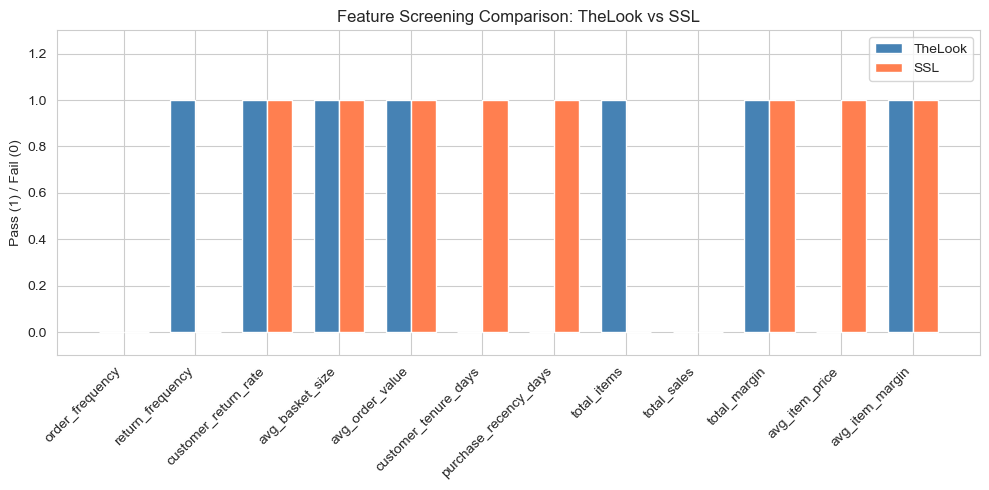

In [9]:
# Visualize pattern comparison
fig, ax = plt.subplots(figsize=(10, 5))

features = pattern_comparison["feature"]
x = np.arange(len(features))
width = 0.35

tl_pass = [1 if s == "pass" else 0 for s in pattern_comparison["thelook_status"]]
ssl_pass = [1 if s == "pass" else 0 for s in pattern_comparison["ssl_status"]]

ax.bar(x - width/2, tl_pass, width, label="TheLook", color="steelblue")
ax.bar(x + width/2, ssl_pass, width, label="SSL", color="coral")

ax.set_xticks(x)
ax.set_xticklabels(features, rotation=45, ha="right")
ax.set_ylabel("Pass (1) / Fail (0)")
ax.set_title("Feature Screening Comparison: TheLook vs SSL")
ax.legend()
ax.set_ylim(-0.1, 1.3)
plt.tight_layout()
plt.show()

## 7. Level 2: Directional Prediction

Apply the TheLook-trained model to SSL data and check if accounts with high actual `total_loss` tend to be flagged as high-risk.

In [10]:
print("=" * 60)
print("LEVEL 2: DIRECTIONAL PREDICTION")
print("=" * 60)

directional_result = validate_directional_predictions(
    ssl_accounts,
    best_model,
    surviving_features,
    scaler=scaler,
)

print(f"\nModel applied: {best_model_name}")
print(f"Features available: {directional_result['n_features_available']}/{len(surviving_features)}")
if directional_result["missing_features"]:
    print(f"Missing features (imputed with 0): {directional_result['missing_features']}")

print(f"\nDirectional Metrics:")
print(f"  Directional accuracy:  {directional_result['directional_accuracy']:.4f}")
print(f"  Rank correlation:      {directional_result['rank_correlation']:.4f} (p={directional_result['rank_pvalue']:.2e})")
print(f"  Predicted high-risk:   {directional_result['predicted_high_pct']:.1f}%")
print(f"  Actual high-loss:      {directional_result['actual_high_pct']:.1f}%")

print(f"\nConfusion Matrix (Predicted vs Actual):")
print(directional_result["confusion_at_directional"])

LEVEL 2: DIRECTIONAL PREDICTION

Model applied: Random Forest
Features available: 7/7

Directional Metrics:
  Directional accuracy:  0.7640
  Rank correlation:      0.7526 (p=0.00e+00)
  Predicted high-risk:   30.7%
  Actual high-loss:      25.0%

Confusion Matrix (Predicted vs Actual):
[[8220 1992]
 [1221 2183]]


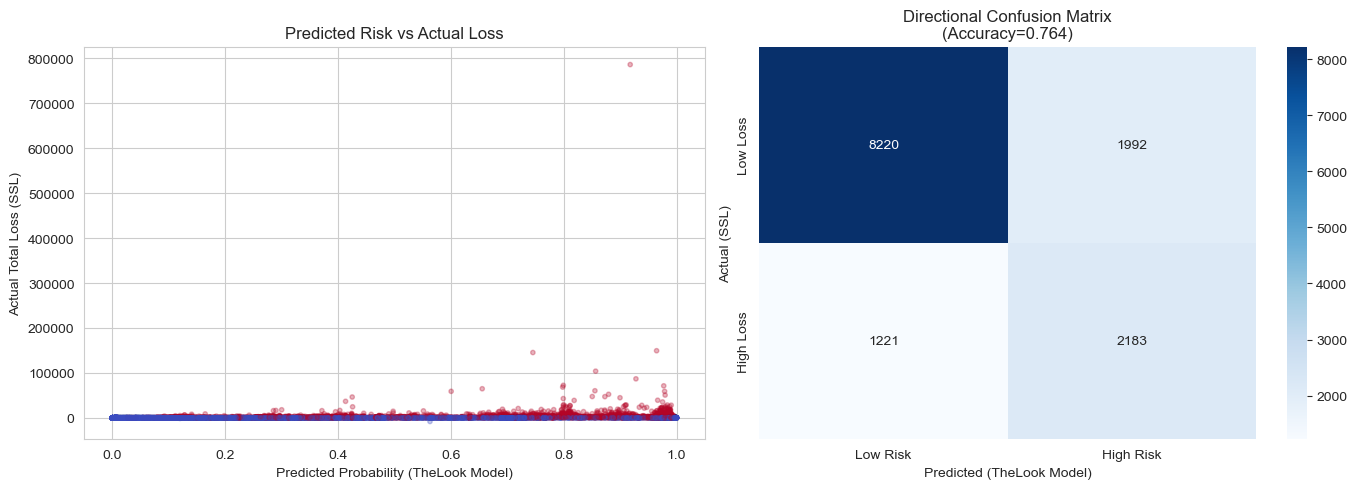

In [11]:
# Visualize directional alignment
pred_df = directional_result["predictions_df"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Predicted probability vs actual loss
ax1 = axes[0]
ax1.scatter(
    pred_df["predicted_probability"],
    pred_df["actual_loss"],
    alpha=0.3, s=10, c=pred_df["actual_high_loss"],
    cmap="coolwarm",
)
ax1.set_xlabel("Predicted Probability (TheLook Model)")
ax1.set_ylabel("Actual Total Loss (SSL)")
ax1.set_title("Predicted Risk vs Actual Loss")

# Plot 2: Confusion matrix heatmap
ax2 = axes[1]
cm = directional_result["confusion_at_directional"]
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Low Risk", "High Risk"],
    yticklabels=["Low Loss", "High Loss"],
    ax=ax2,
)
ax2.set_xlabel("Predicted (TheLook Model)")
ax2.set_ylabel("Actual (SSL)")
ax2.set_title(f"Directional Confusion Matrix\n(Accuracy={directional_result['directional_accuracy']:.3f})")

plt.tight_layout()
plt.show()

## 8. Validation Summary

In [12]:
print("=" * 60)
print("VALIDATION SUMMARY")
print("=" * 60)

summary = build_validation_summary(pattern_comparison, directional_result)

print()
for _, row in summary.iterrows():
    print(f"  {row['metric']:40s} {row['value']}")

VALIDATION SUMMARY

  pattern_features_compared                12.0
  pattern_agreement_count                  7.0
  pattern_agreement_pct                    58.3
  pattern_both_pass                        5.0
  pattern_both_fail                        2.0
  directional_accuracy                     0.764
  directional_rank_correlation             0.7526
  directional_rank_pvalue                  0.0
  ssl_accounts_evaluated                   13616.0
  features_available                       7.0
  features_missing                         0.0
  predicted_high_risk_pct                  30.7
  actual_high_loss_pct                     25.0


## 9. Export Validation Artifacts

In [13]:
print("=" * 60)
print("EXPORT VALIDATION ARTIFACTS")
print("=" * 60)

reports_dir = REPORTS_DIR / "rq3"
reports_dir.mkdir(parents=True, exist_ok=True)

# SSL feature mapping (account-level features)
ssl_feature_cols = [f for f in RQ3_CANDIDATE_FEATURES if f in ssl_accounts.columns]
ssl_accounts[ssl_feature_cols].describe().to_csv(
    reports_dir / "rq3_ssl_feature_mapping.csv"
)
print(f"  Saved: rq3_ssl_feature_mapping.csv")

# Pattern comparison
pattern_comparison.to_csv(
    reports_dir / "rq3_ssl_feature_screening.csv", index=False
)
print(f"  Saved: rq3_ssl_feature_screening.csv")

# Directional predictions
pred_df.to_csv(
    reports_dir / "rq3_ssl_directional_validation.csv", index=False
)
print(f"  Saved: rq3_ssl_directional_validation.csv")

# Validation summary
summary.to_csv(
    reports_dir / "rq3_validation_summary.csv", index=False
)
print(f"  Saved: rq3_validation_summary.csv")

print(f"\nAll validation artifacts saved to: {reports_dir}")

EXPORT VALIDATION ARTIFACTS
  Saved: rq3_ssl_feature_mapping.csv
  Saved: rq3_ssl_feature_screening.csv
  Saved: rq3_ssl_directional_validation.csv
  Saved: rq3_validation_summary.csv

All validation artifacts saved to: c:\Users\folij077\OneDrive - GUSCanada\SCHOOL\Winter 2026\Capstone\bQuery_theLook\unfc-capstone-project\reports\rq3


## 10. Conclusion

In [14]:
print("=" * 60)
print("RQ3 EXTERNAL VALIDATION CONCLUSION")
print("=" * 60)

print(f"\nTheLook Baseline:")
print(f"  Best model:            {best_model_name}")
print(f"  Test AUC:              {hypothesis['best_auc']:.4f}")
print(f"  Surviving features:    {len(surviving_features)}")

print(f"\nLevel 1 — Pattern Validation:")
print(f"  Features compared:     {len(pattern_comparison)}")
print(f"  Agreement rate:        {n_agree}/{n_total} ({n_agree/n_total*100:.1f}%)")
print(f"  Both pass:             {n_both_pass}")

print(f"\nLevel 2 — Directional Prediction:")
print(f"  SSL accounts:          {directional_result['n_accounts']:,}")
print(f"  Directional accuracy:  {directional_result['directional_accuracy']:.4f}")
print(f"  Rank correlation:      {directional_result['rank_correlation']:.4f} (p={directional_result['rank_pvalue']:.2e})")

# Interpret rank correlation
rc = directional_result["rank_correlation"]
if rc > 0.5:
    interpretation = "Strong positive directional alignment — model generalizes well."
elif rc > 0.3:
    interpretation = "Moderate positive directional alignment — model shows transferable patterns."
elif rc > 0.1:
    interpretation = "Weak positive directional alignment — some transferability observed."
elif rc > -0.1:
    interpretation = "No meaningful directional alignment — model does not transfer."
else:
    interpretation = "Negative alignment — model predictions inversely related to actual loss."

print(f"\nInterpretation: {interpretation}")

RQ3 EXTERNAL VALIDATION CONCLUSION

TheLook Baseline:
  Best model:            Random Forest
  Test AUC:              0.9798
  Surviving features:    7

Level 1 — Pattern Validation:
  Features compared:     12
  Agreement rate:        7/12 (58.3%)
  Both pass:             5

Level 2 — Directional Prediction:
  SSL accounts:          13,616
  Directional accuracy:  0.7640
  Rank correlation:      0.7526 (p=0.00e+00)

Interpretation: Strong positive directional alignment — model generalizes well.
